# ACC102 Track 2: K-Pop Industry Data Analysis
**Objective:** This notebook processes and analyzes historical K-Pop group data to uncover industry trends, market saturation, and group longevity models. 

## Phase 1 & 2: Setup and Data Cleaning
In this section, we import necessary libraries, load the dataset using relative paths for reproducibility, and clean the data (date parsing, handling missing values, and formatting data types).

In [1]:
# !pip install pandas numpy plotly

# Import necessary libraries for data manipulation and advanced visualization
import pandas as pd
import numpy as np
import plotly.express as px

# ---------------------------------------------------------
# Phase 1: Setup & Import
# ---------------------------------------------------------
# Load the dataset using a relative path to ensure reproducibility on the marker's machine
file_path = 'data/kpopgroups.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: Could not find the file at '{file_path}'. Please check your directory structure.")

# ---------------------------------------------------------
# Phase 2: Data Cleaning
# ---------------------------------------------------------
if 'df' in locals():
    # 1. Date Parsing: Convert the 'Debut' column from string to datetime objects
    # The dataset uses Day/Month/Year format. errors='coerce' turns invalid dates into NaT
    df['Debut'] = pd.to_datetime(df['Debut'], format='%d/%m/%Y', errors='coerce')
    
    # 2. Handling Missing Values: Fill NaN values in categorical columns with 'Unknown'
    df['Short'] = df['Short'].fillna('Unknown')
    df['Fanclub Name'] = df['Fanclub Name'].fillna('Unknown')
    
    # 3. Data Type Formatting: Ensure member count columns are integers
    # Convert to numeric, handle any potential strings by converting to NaN, fill NaN with 0, and cast to int
    df['Members'] = pd.to_numeric(df['Members'], errors='coerce').fillna(0).astype(int)
    df['Orig Memb'] = pd.to_numeric(df['Orig Memb'], errors='coerce').fillna(0).astype(int)
    
    # 4. Standardize String Formatting: Remove leading/trailing spaces in company names
    df['Company'] = df['Company'].astype(str).str.strip()
    
    # Verify the changes: check data types and look for any remaining null values
    print("\n--- Data Information After Cleaning ---")
    display(df.info())
    display(df.head())

Dataset loaded successfully.

--- Data Information After Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Name          426 non-null    object        
 1   Short         426 non-null    object        
 2   Korean Name   426 non-null    object        
 3   Gender        426 non-null    object        
 4   Debut         424 non-null    datetime64[ns]
 5   Company       426 non-null    object        
 6   Members       426 non-null    int64         
 7   Orig Memb     426 non-null    int64         
 8   Fanclub Name  426 non-null    object        
 9   Active        426 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 33.4+ KB


None

,Name,Short,Korean Name,Gender,Debut,Company,Members,Orig Memb,Fanclub Name,Active
0,(G)I-DLE,Unknown,(여자)아이들,Female,2018-05-02,Cube,5,6,Unknown,Yes
1,100%,Unknown,백퍼센트,Male,2012-09-18,TOP Media,4,7,Perfection,Yes
2,14U,Unknown,원포유,Male,2017-04-17,BG,14,14,Unknown,No
3,15&,Unknown,피프틴앤드,Female,2012-10-05,JYP,2,2,Unknown,No
4,1TEAM,Unknown,원팀,Male,2019-03-27,LiveWorks,5,5,Unknown,No


In [2]:
# ---------------------------------------------------------
# Phase 3: Feature Engineering
# ---------------------------------------------------------
# 1. Extract the year of debut for time-series trend analysis
df['Debut_Year'] = df['Debut'].dt.year

# 2. Calculate Member Retention Rate (Current Members / Original Members)
# We replace 0 with NaN temporarily to avoid 'division by zero' errors, then fill resulting NaNs with 0
df['Retention_Rate'] = (df['Members'] / df['Orig Memb'].replace(0, np.nan)).fillna(0) * 100

# 3. Categorize agencies into Tiers based on market share (total groups produced)
company_counts = df['Company'].value_counts()

def classify_agency(count):
    if count >= 10:
        return 'Tier 1 (Major)'
    elif count >= 4:
        return 'Tier 2 (Mid-size)'
    else:
        return 'Boutique (Small)'

# Map the counts back to the dataframe and apply our classification function
df['Agency_Tier'] = df['Company'].map(company_counts).apply(classify_agency)

# ---------------------------------------------------------
# Phase 4: Exploratory Data Analysis (EDA)
# ---------------------------------------------------------
# Aggregation 1: Market Saturation Trend (Debuts per Year)
# Dropna ensures we don't count groups with missing debut dates
debuts_per_year = df.dropna(subset=['Debut_Year']).groupby('Debut_Year').size().reset_index(name='Total_Debuts')

# Aggregation 2: Top 10 Agencies by Total Groups Produced
top_10_agencies = company_counts.head(10).reset_index()
top_10_agencies.columns = ['Company', 'Total_Groups']

# Aggregation 3: Industry Survival Rate by Gender
# Crosstab provides a clean frequency table for categorical variables
survival_table = pd.crosstab(df['Gender'], df['Active'])
# Calculate the percentage of 'Yes' (Active) out of the total
if 'Yes' in survival_table.columns and 'No' in survival_table.columns:
    survival_table['Survival_Rate(%)'] = (survival_table['Yes'] / (survival_table['Yes'] + survival_table['No']) * 100).round(2)

# Display the aggregated dataframes to verify our insights
print("\n--- Insight 1: Top 10 Agencies by Market Output ---")
display(top_10_agencies)

print("\n--- Insight 2: K-Pop Group Survival Rate by Gender ---")
display(survival_table)


--- Insight 1: Top 10 Agencies by Market Output ---


,Company,Total_Groups
0,SM,14
1,JYP,11
2,FNC,8
3,YG,7
4,Cube,6
5,Starship,6
6,MBK,5
7,Woollim,5
8,Big Hit,5
9,DSP,5



--- Insight 2: K-Pop Group Survival Rate by Gender ---


Active,Hiatus,No,Pre-Debut,Yes,Survival_Rate(%)
Gender,,,,,
Female,7,98,1,110,52.88
Male,7,49,0,154,75.86


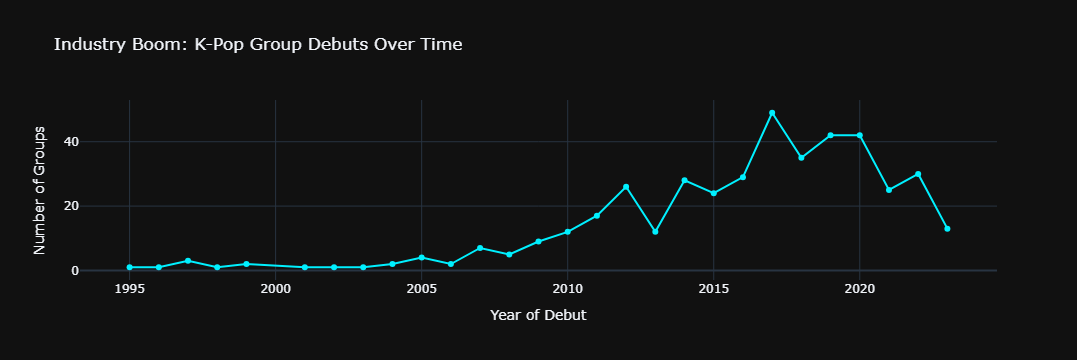

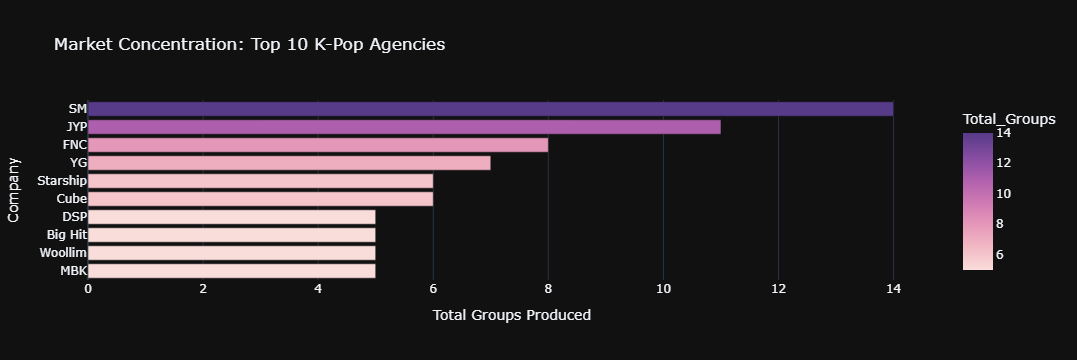

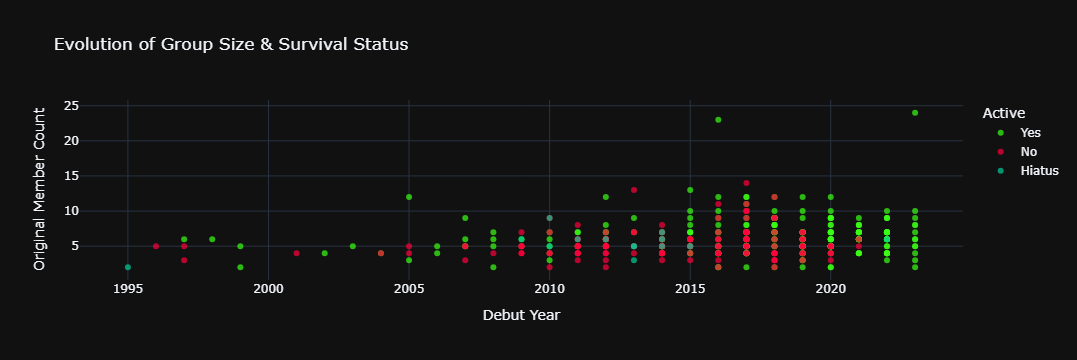

In [4]:
# ---------------------------------------------------------
# Phase 5: Advanced Data Visualization with Plotly
# ---------------------------------------------------------
# Set a global dark theme for a futuristic and professional aesthetic
global_template = 'plotly_dark'

# --- Chart 1: Market Saturation Trend (Line Chart) ---
# Visualizing the boom of K-Pop group debuts over the years
fig_trend = px.line(
    debuts_per_year, 
    x='Debut_Year', 
    y='Total_Debuts', 
    title='Industry Boom: K-Pop Group Debuts Over Time',
    markers=True,
    template=global_template,
    color_discrete_sequence=['#00F0FF'] # Cyberpunk cyan accent
)
# Refine layout for minimal aesthetic
fig_trend.update_layout(xaxis_title='Year of Debut', yaxis_title='Number of Groups')
fig_trend.show()

# --- Chart 2: Top 10 Agencies Dominance (Horizontal Bar Chart) ---
# Highlighting market concentration among top companies
fig_agencies = px.bar(
    top_10_agencies, 
    x='Total_Groups', 
    y='Company', 
    orientation='h',
    title='Market Concentration: Top 10 K-Pop Agencies',
    template=global_template,
    color='Total_Groups',
    color_continuous_scale='Purpor' # High-end purple gradient
)
# Sort bars from largest to smallest (top to bottom)
fig_agencies.update_layout(yaxis={'categoryorder':'total ascending'}, xaxis_title='Total Groups Produced')
fig_agencies.show()

# --- Chart 3: Group Size Evolution & Longevity (Interactive Scatter Plot) ---
# Analyzing if newer groups are larger and how size correlates with active status
# Drop missing dates for plotting accuracy
df_plot = df.dropna(subset=['Debut_Year']).copy()

fig_scatter = px.scatter(
    df_plot, 
    x='Debut_Year', 
    y='Orig Memb', 
    color='Active', 
    hover_name='Name',
    hover_data=['Company', 'Members', 'Retention_Rate'],
    title='Evolution of Group Size & Survival Status',
    template=global_template,
    color_discrete_map={'Yes': '#39FF14', 'No': '#FF003C'}, # Neon green for Active, Neon red for Inactive
    opacity=0.7
)
# Update axes to ensure clarity
fig_scatter.update_layout(xaxis_title='Debut Year', yaxis_title='Original Member Count')
fig_scatter.show()